# EDA — Itinerarios (TravExperience)

**Fuente real**: tabla `Itinerary` (MySQL) — campos `startDate`,
`endDate`, `estimatedBudget`, `itineraryDetails`, `destination`.

**Nota**: muestra sintética (misma lógica que `generateSyntheticData` en
`scripts/trainBudgetModel.js`). Reemplazar por
`Data/Raw/itineraries_raw.csv` cuando el ETL esté conectado a la BD real.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(7)


## 1. Carga de datos (sintéticos por ahora — reemplazar por real)

In [2]:
N = 400
destinos = ['Cancún', 'Ciudad de México', 'Guadalajara', 'Oaxaca', 'Puerto Vallarta',
            'Mérida', 'Monterrey', 'San Miguel de Allende']

duracion_dias = np.random.randint(1, 15, N)
num_actividades = np.random.randint(0, 10, N)
presupuesto = duracion_dias * 650 + num_actividades * 200 + np.random.normal(0, 200, N)
presupuesto = np.clip(presupuesto, 300, None)

df_itin = pd.DataFrame({
    'itinerary_id': range(1, N + 1),
    'destino': np.random.choice(destinos, N),
    'duracionDias': duracion_dias,
    'numActividades': num_actividades,
    'estimatedBudget': presupuesto.round(2),
})
df_itin.head()


,itinerary_id,destino,duracionDias,numActividades,estimatedBudget
0,1,Monterrey,5,7,4338.65
1,2,Cancún,10,5,7525.42
2,3,Puerto Vallarta,7,7,5933.06
3,4,Oaxaca,4,5,3539.54
4,5,Oaxaca,4,3,3031.46


## 2. Estadísticas descriptivas

In [3]:
df_itin.describe()

,itinerary_id,duracionDias,numActividades,estimatedBudget
count,400.000000,400.000000,400.000000,400.000000
mean,200.500000,7.712500,4.450000,5892.475675
std,115.614301,4.104505,2.864964,2714.165595
min,1.000000,1.000000,0.000000,300.000000
25%,100.750000,4.000000,2.000000,3739.712500
50%,200.500000,8.000000,4.500000,5955.035000
75%,300.250000,12.000000,7.000000,8187.790000
max,400.000000,14.000000,9.000000,11038.650000


## 3. Duración de viajes

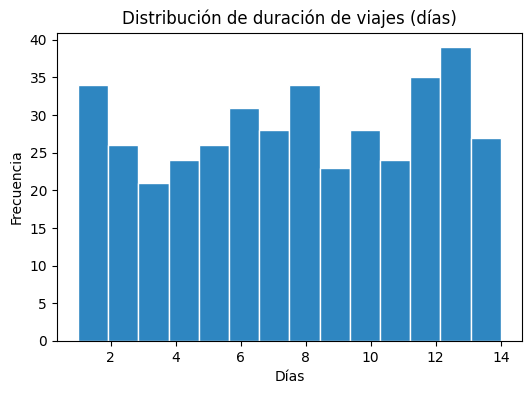

In [4]:
plt.figure(figsize=(6,4))
plt.hist(df_itin['duracionDias'], bins=14, color='#2E86C1', edgecolor='white')
plt.title('Distribución de duración de viajes (días)')
plt.xlabel('Días')
plt.ylabel('Frecuencia')
plt.show()


## 4. Presupuesto estimado por duración (relación esperada)

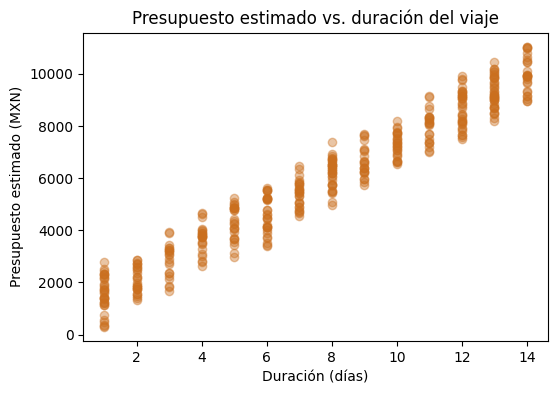

In [5]:
plt.figure(figsize=(6,4))
plt.scatter(df_itin['duracionDias'], df_itin['estimatedBudget'], alpha=0.4, color='#CA6F1E')
plt.title('Presupuesto estimado vs. duración del viaje')
plt.xlabel('Duración (días)')
plt.ylabel('Presupuesto estimado (MXN)')
plt.show()


## 5. Itinerarios por destino

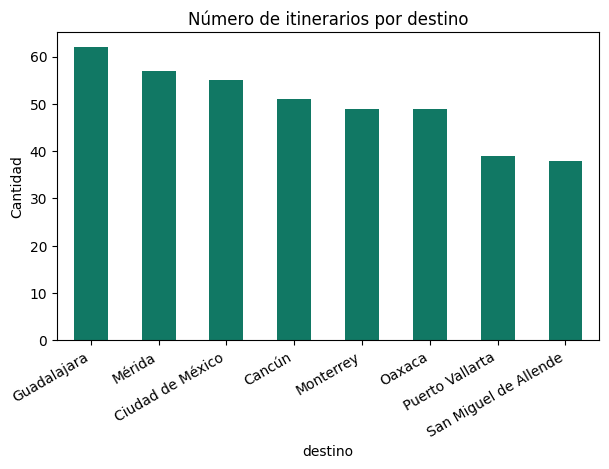

In [6]:
df_itin['destino'].value_counts().plot(kind='bar', figsize=(7,4), color='#117864')
plt.title('Número de itinerarios por destino')
plt.ylabel('Cantidad')
plt.xticks(rotation=30, ha='right')
plt.show()


## 6. Correlación entre variables numéricas

In [7]:
corr = df_itin[['duracionDias', 'numActividades', 'estimatedBudget']].corr()
corr


,duracionDias,numActividades,estimatedBudget
duracionDias,1.000000,-0.037991,0.975078
numActividades,-0.037991,1.000000,0.173480
estimatedBudget,0.975078,0.173480,1.000000


## 7. Conclusiones preliminares

- Se confirma una relación aproximadamente lineal entre duración del
  viaje y presupuesto estimado — consistente con la regla usada por el
  modelo de regresión (`~650 MXN/día + 200 MXN/actividad`).
- La correlación entre `duracionDias` y `estimatedBudget` es alta, lo
  que respalda que estas 2 features sean suficientes para un primer
  modelo de regresión razonable.
- El número de actividades tiene menor varianza que la duración — vale
  la pena, con datos reales, verificar si aporta suficiente señal por
  sí solo o si el modelo depende casi enteramente de la duración.

**Pendiente**: repetir con `itineraries_raw.csv` real y verificar si la
relación lineal se mantiene, o si aparecen patrones no lineales por
destino/temporada que ameriten agregar esas variables al modelo.
